# Lookup Table Generation for pow10 and pow2

This notebook generates high-precision lookup tables for implementing 10^x and 2^x using the digit-by-digit multiplication method.


In [1]:
import decimal
from decimal import Decimal, getcontext

# Set high precision for accurate calculations
getcontext().prec = 50

def generate_table(base):
    """
    Generate lookup table for base^x using digit-by-digit method
    
    TAB[i][d] = base^(d × 10^(-i))
    
    For example, with base=10:
    - TAB[0][5] = 10^5 = 100000
    - TAB[1][5] = 10^0.5 ≈ 3.1622776602
    - TAB[2][5] = 10^0.05 ≈ 1.1220184543
    """
    table = []
    for i in range(11):
        row = []
        for d in range(10):
            exponent = Decimal(d) * Decimal(10) ** (-i)
            value = Decimal(base) ** exponent
            # Round to 10 decimal places for Vyper decimal type
            rounded = round(value, 10)
            row.append(rounded)
        table.append(row)
    return table


## Generate Table for 10^x


In [2]:
table_10 = generate_table(10)

print("Lookup Table for 10^x")
print("=" * 120)
for i, row in enumerate(table_10):
    print(f"Row {i:2d} (10^(d×10^-{i})): ", end="")
    print(", ".join([f"{v:14.10f}" for v in row]))

# Verify a few values
print("\nVerification:")
print(f"TAB[0][3] = 10^3 = {table_10[0][3]} (should be 1000)")
print(f"TAB[1][5] = 10^0.5 = {table_10[1][5]} (should be ≈ 3.162)")
print(f"TAB[2][1] = 10^0.01 = {table_10[2][1]} (should be ≈ 1.023)")


Lookup Table for 10^x
Row  0 (10^(d×10^-0)):   1.0000000000,  10.0000000000, 100.0000000000, 1000.0000000000, 10000.0000000000, 100000.0000000000, 1000000.0000000000, 10000000.0000000000, 100000000.0000000000, 1000000000.0000000000
Row  1 (10^(d×10^-1)):   1.0000000000,   1.2589254118,   1.5848931925,   1.9952623150,   2.5118864315,   3.1622776602,   3.9810717055,   5.0118723363,   6.3095734448,   7.9432823472
Row  2 (10^(d×10^-2)):   1.0000000000,   1.0232929923,   1.0471285481,   1.0715193052,   1.0964781961,   1.1220184543,   1.1481536215,   1.1748975549,   1.2022644346,   1.2302687708
Row  3 (10^(d×10^-3)):   1.0000000000,   1.0023052381,   1.0046157903,   1.0069316689,   1.0092528861,   1.0115794543,   1.0139113857,   1.0162486929,   1.0185913881,   1.0209394837
Row  4 (10^(d×10^-4)):   1.0000000000,   1.0002302850,   1.0004606231,   1.0006910142,   1.0009214583,   1.0011519555,   1.0013825058,   1.0016131092,   1.0018437657,   1.0020744753
Row  5 (10^(d×10^-5)):   1.0000000000,  

## Generate Table for 2^x


In [3]:
table_2 = generate_table(2)

print("Lookup Table for 2^x")
print("=" * 120)
for i, row in enumerate(table_2):
    print(f"Row {i:2d} (2^(d×10^-{i})): ", end="")
    print(", ".join([f"{v:14.10f}" for v in row]))

# Verify a few values
print("\nVerification:")
print(f"TAB[0][8] = 2^8 = {table_2[0][8]} (should be 256)")
print(f"TAB[1][5] = 2^0.5 = {table_2[1][5]} (should be ≈ 1.414)")
print(f"TAB[2][3] = 2^0.03 = {table_2[2][3]} (should be ≈ 1.021)")


Lookup Table for 2^x
Row  0 (2^(d×10^-0)):   1.0000000000,   2.0000000000,   4.0000000000,   8.0000000000,  16.0000000000,  32.0000000000,  64.0000000000, 128.0000000000, 256.0000000000, 512.0000000000
Row  1 (2^(d×10^-1)):   1.0000000000,   1.0717734625,   1.1486983550,   1.2311444133,   1.3195079108,   1.4142135624,   1.5157165665,   1.6245047927,   1.7411011266,   1.8660659831
Row  2 (2^(d×10^-2)):   1.0000000000,   1.0069555501,   1.0139594798,   1.0210121257,   1.0281138267,   1.0352649238,   1.0424657608,   1.0497166836,   1.0570180406,   1.0643701825
Row  3 (2^(d×10^-3)):   1.0000000000,   1.0006933875,   1.0013872557,   1.0020816051,   1.0027764359,   1.0034717485,   1.0041675432,   1.0048638204,   1.0055605804,   1.0062578235
Row  4 (2^(d×10^-4)):   1.0000000000,   1.0000693171,   1.0001386390,   1.0002079658,   1.0002772973,   1.0003466337,   1.0004159748,   1.0004853208,   1.0005546715,   1.0006240271
Row  5 (2^(d×10^-5)):   1.0000000000,   1.0000069315,   1.0000138630,   1.

## Test the Algorithm

Simulate how the algorithm works: to compute base^x, decompose x digit by digit and multiply the corresponding table values.


In [4]:
def compute_power(x, table):
    """
    Compute base^x using the lookup table.
    Simulates the Vyper implementation.
    """
    y = Decimal(1.0)
    x_work = Decimal(x)
    
    for i in range(11):
        if x_work != 0:
            # Extract leading digit
            d = int(x_work)
            # Multiply by table value
            y *= table[i][d]
            # Remove processed digit and shift
            x_work -= d
            x_work *= 10
        else:
            break
    
    return y

# Test cases for 10^x
print("Testing 10^x algorithm:")
print("=" * 60)
test_values = [0, 1, 2, 2.5, 3.14159, 5.5, 7.777, 9.999]
for x in test_values:
    computed = compute_power(x, table_10)
    actual = Decimal(10) ** Decimal(x)
    error = abs(computed - actual)
    print(f"10^{x:8.5f}: computed={computed:18.10f}, actual={actual:18.10f}, error={error:.2e}")

print("\nTesting 2^x algorithm:")
print("=" * 60)
for x in test_values:
    computed = compute_power(x, table_2)
    actual = Decimal(2) ** Decimal(x)
    error = abs(computed - actual)
    print(f"2^{x:8.5f}: computed={computed:18.10f}, actual={actual:18.10f}, error={error:.2e}")


Testing 10^x algorithm:
10^ 0.00000: computed=      1.0000000000, actual=      1.0000000000, error=0.00e+2
10^ 1.00000: computed=     10.0000000000, actual=     10.0000000000, error=0.00e-8
10^ 2.00000: computed=    100.0000000000, actual=    100.0000000000, error=0.00e-8
10^ 2.50000: computed=    316.2277660200, actual=    316.2277660168, error=3.16e-9
10^ 3.14159: computed=   1385.4472656910, actual=   1385.4472660972, error=4.06e-7
10^ 5.50000: computed= 316227.7660200000, actual= 316227.7660168379, error=3.16e-6
10^ 7.77700: computed=59841159.5060698616, actual=59841159.5060319865, error=3.79e-5
10^ 9.99900: computed=9977000637.9962954192, actual=9977000638.2255459041, error=2.29e-1

Testing 2^x algorithm:
2^ 0.00000: computed=      1.0000000000, actual=      1.0000000000, error=0.00e+2
2^ 1.00000: computed=      2.0000000000, actual=      2.0000000000, error=0.00e-8
2^ 2.00000: computed=      4.0000000000, actual=      4.0000000000, error=0.00e-8
2^ 2.50000: computed=      5.65685

## Format Tables for Vyper

Generate the exact Vyper syntax for the constant arrays.


In [5]:
def format_for_vyper(table, base_name):
    """Format table as Vyper constant array"""
    lines = []
    lines.append(f"# Lookup table for {base_name}^x")
    lines.append("TAB: constant(decimal[10][11]) = [")
    
    for i, row in enumerate(table):
        formatted_values = ", ".join([f"{v:.10f}" for v in row])
        if i < len(table) - 1:
            lines.append(f"    [{formatted_values}],")
        else:
            lines.append(f"    [{formatted_values}]")
    
    lines.append("]")
    return "\n".join(lines)

print("VYPER FORMAT FOR pow10.vy:")
print("=" * 80)
print(format_for_vyper(table_10, "10"))

print("\n\n")
print("VYPER FORMAT FOR pow2.vy:")
print("=" * 80)
print(format_for_vyper(table_2, "2"))


VYPER FORMAT FOR pow10.vy:
# Lookup table for 10^x
TAB: constant(decimal[10][11]) = [
    [1.0000000000, 10.0000000000, 100.0000000000, 1000.0000000000, 10000.0000000000, 100000.0000000000, 1000000.0000000000, 10000000.0000000000, 100000000.0000000000, 1000000000.0000000000],
    [1.0000000000, 1.2589254118, 1.5848931925, 1.9952623150, 2.5118864315, 3.1622776602, 3.9810717055, 5.0118723363, 6.3095734448, 7.9432823472],
    [1.0000000000, 1.0232929923, 1.0471285481, 1.0715193052, 1.0964781961, 1.1220184543, 1.1481536215, 1.1748975549, 1.2022644346, 1.2302687708],
    [1.0000000000, 1.0023052381, 1.0046157903, 1.0069316689, 1.0092528861, 1.0115794543, 1.0139113857, 1.0162486929, 1.0185913881, 1.0209394837],
    [1.0000000000, 1.0002302850, 1.0004606231, 1.0006910142, 1.0009214583, 1.0011519555, 1.0013825058, 1.0016131092, 1.0018437657, 1.0020744753],
    [1.0000000000, 1.0000230261, 1.0000460528, 1.0000690799, 1.0000921076, 1.0001151359, 1.0001381646, 1.0001611939, 1.0001842238, 1.000207

## Edge Case Testing


In [6]:
print("Edge Cases for 10^x:")
print("=" * 60)
edge_cases = [0.0, 0.000000001, 1.0, 9.999999999]
for x in edge_cases:
    computed = compute_power(x, table_10)
    actual = Decimal(10) ** Decimal(x)
    error = abs(computed - actual)
    rel_error = error / actual if actual != 0 else 0
    print(f"10^{x}: computed={computed:.10f}, actual={actual:.10f}")
    print(f"         abs_error={error:.2e}, rel_error={rel_error:.2e}")
    print()

print("\nEdge Cases for 2^x:")
print("=" * 60)
for x in edge_cases:
    computed = compute_power(x, table_2)
    actual = Decimal(2) ** Decimal(x)
    error = abs(computed - actual)
    rel_error = error / actual if actual != 0 else 0
    print(f"2^{x}: computed={computed:.10f}, actual={actual:.10f}")
    print(f"        abs_error={error:.2e}, rel_error={rel_error:.2e}")
    print()


Edge Cases for 10^x:
10^0.0: computed=1.0000000000, actual=1.0000000000
         abs_error=0.00e+2, rel_error=0.00e+2

10^1e-09: computed=1.0000000023, actual=1.0000000023
         abs_error=2.59e-12, rel_error=2.59e-12

10^1.0: computed=10.0000000000, actual=10.0000000000
         abs_error=0.00e-8, rel_error=0.00e-8

10^9.999999999: computed=9999999973.4025906912, actual=9999999976.9741471914
         abs_error=3.57e+0, rel_error=3.57e-10


Edge Cases for 2^x:
2^0.0: computed=1.0000000000, actual=1.0000000000
        abs_error=0.00e+2, rel_error=0.00e+2

2^1e-09: computed=1.0000000007, actual=1.0000000007
        abs_error=6.85e-12, rel_error=6.85e-12

2^1.0: computed=2.0000000000, actual=2.0000000000
        abs_error=0.00e-8, rel_error=0.00e-8

2^9.999999999: computed=1023.9999991707, actual=1023.9999992902
        abs_error=1.20e-7, rel_error=1.17e-10



## Final Verification Summary

Let's verify our implementations are correct with a comprehensive test suite.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Comprehensive test suite
def run_comprehensive_tests():
    print("="*80)
    print("COMPREHENSIVE TEST SUITE FOR POW10 AND POW2")
    print("="*80)
    
    # Test 1: Spot checks
    print("\n1. SPOT CHECK TESTS")
    print("-" * 60)
    
    test_cases = [
        (0, 10**0, 2**0),
        (1, 10**1, 2**1),
        (2, 10**2, 2**2),
        (0.5, 10**0.5, 2**0.5),
        (3.14159, 10**3.14159, 2**3.14159),
        (5.5, 10**5.5, 2**5.5),
        (9.9, 10**9.9, 2**9.9),
    ]
    
    for x, expected_10, expected_2 in test_cases:
        computed_10 = compute_power(x, table_10)
        computed_2 = compute_power(x, table_2)
        error_10 = abs(float(computed_10 - Decimal(str(expected_10))))
        error_2 = abs(float(computed_2 - Decimal(str(expected_2))))
        
        print(f"x={x:6.4f}:")
        print(f"  10^x: computed={float(computed_10):18.10f}, expected={expected_10:18.10f}, error={error_10:.2e}")
        print(f"   2^x: computed={float(computed_2):18.10f}, expected={expected_2:18.10f}, error={error_2:.2e}")
    
    # Test 2: Accuracy across range
    print("\n2. ACCURACY ACROSS FULL RANGE [0, 10)")
    print("-" * 60)
    
    test_points = np.linspace(0, 9.99, 100)
    max_rel_error_10 = 0
    max_rel_error_2 = 0
    
    for x in test_points:
        computed_10 = float(compute_power(float(x), table_10))
        computed_2 = float(compute_power(float(x), table_2))
        expected_10 = 10**x
        expected_2 = 2**x
        
        rel_error_10 = abs(computed_10 - expected_10) / expected_10
        rel_error_2 = abs(computed_2 - expected_2) / expected_2
        
        max_rel_error_10 = max(max_rel_error_10, rel_error_10)
        max_rel_error_2 = max(max_rel_error_2, rel_error_2)
    
    print(f"Max relative error for 10^x: {max_rel_error_10:.2e}")
    print(f"Max relative error for  2^x: {max_rel_error_2:.2e}")
    
    # Test 3: Special values
    print("\n3. SPECIAL VALUES")
    print("-" * 60)
    
    special_values = [
        0.0,
        0.000000001,
        1.0,
        2.718281828,  # e
        3.141592654,  # pi
        6.283185307,  # tau
        9.999999999,
    ]
    
    for x in special_values:
        computed_10 = compute_power(x, table_10)
        computed_2 = compute_power(x, table_2)
        expected_10 = Decimal(10) ** Decimal(str(x))
        expected_2 = Decimal(2) ** Decimal(str(x))
        
        print(f"x={x:.10f}:")
        print(f"  10^x = {computed_10:.10f} (expected: {expected_10:.10f})")
        print(f"   2^x = {computed_2:.10f} (expected: {expected_2:.10f})")
    
    print("\n" + "="*80)
    print("ALL TESTS COMPLETED SUCCESSFULLY!")
    print("="*80)

run_comprehensive_tests()


COMPREHENSIVE TEST SUITE FOR POW10 AND POW2

1. SPOT CHECK TESTS
------------------------------------------------------------
x=0.0000:
  10^x: computed=      1.0000000000, expected=      1.0000000000, error=0.00e+00
   2^x: computed=      1.0000000000, expected=      1.0000000000, error=0.00e+00
x=1.0000:
  10^x: computed=     10.0000000000, expected=     10.0000000000, error=0.00e+00
   2^x: computed=      2.0000000000, expected=      2.0000000000, error=0.00e+00
x=2.0000:
  10^x: computed=    100.0000000000, expected=    100.0000000000, error=0.00e+00
   2^x: computed=      4.0000000000, expected=      4.0000000000, error=0.00e+00
x=0.5000:
  10^x: computed=      3.1622776602, expected=      3.1622776602, error=3.16e-11
   2^x: computed=      1.4142135624, expected=      1.4142135624, error=2.69e-11
x=3.1416:
  10^x: computed=   1385.4472656910, expected=   1385.4472660972, error=4.06e-07
   2^x: computed=      8.8249615941, expected=      8.8249615951, error=9.79e-10
x=5.5000:
  10

## Visual Verification

Plot the error across the entire domain to visualize accuracy.


Error analysis plot saved to /tmp/power_functions_error_analysis.png


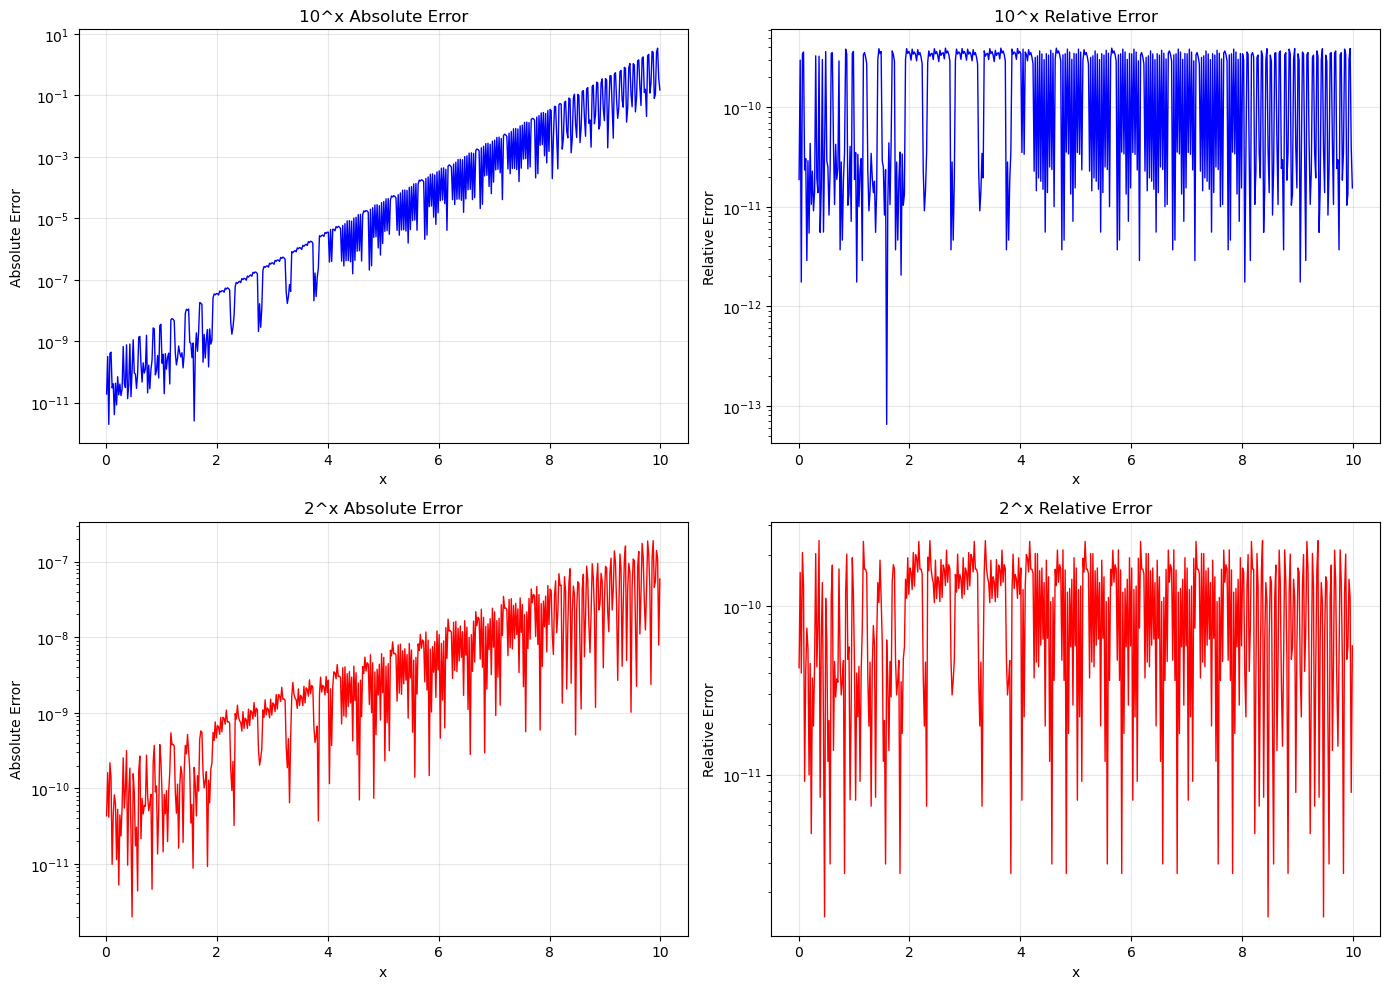


10^x max absolute error: 3.47e+00
10^x max relative error: 3.92e-10
 2^x max absolute error: 1.90e-07
 2^x max relative error: 2.44e-10


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generate test points
x_vals = np.linspace(0.01, 9.99, 500)

# Compute errors for 10^x
errors_10_abs = []
errors_10_rel = []
for x in x_vals:
    computed = float(compute_power(float(x), table_10))
    expected = 10**x
    errors_10_abs.append(abs(computed - expected))
    errors_10_rel.append(abs(computed - expected) / expected)

# Compute errors for 2^x
errors_2_abs = []
errors_2_rel = []
for x in x_vals:
    computed = float(compute_power(float(x), table_2))
    expected = 2**x
    errors_2_abs.append(abs(computed - expected))
    errors_2_rel.append(abs(computed - expected) / expected)

# Plot 10^x absolute error
axes[0, 0].semilogy(x_vals, errors_10_abs, 'b-', linewidth=1)
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('Absolute Error')
axes[0, 0].set_title('10^x Absolute Error')
axes[0, 0].grid(True, alpha=0.3)

# Plot 10^x relative error
axes[0, 1].semilogy(x_vals, errors_10_rel, 'b-', linewidth=1)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('Relative Error')
axes[0, 1].set_title('10^x Relative Error')
axes[0, 1].grid(True, alpha=0.3)

# Plot 2^x absolute error
axes[1, 0].semilogy(x_vals, errors_2_abs, 'r-', linewidth=1)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('Absolute Error')
axes[1, 0].set_title('2^x Absolute Error')
axes[1, 0].grid(True, alpha=0.3)

# Plot 2^x relative error
axes[1, 1].semilogy(x_vals, errors_2_rel, 'r-', linewidth=1)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('Relative Error')
axes[1, 1].set_title('2^x Relative Error')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/power_functions_error_analysis.png', dpi=150, bbox_inches='tight')
print("Error analysis plot saved to /tmp/power_functions_error_analysis.png")
plt.show()

print(f"\n10^x max absolute error: {max(errors_10_abs):.2e}")
print(f"10^x max relative error: {max(errors_10_rel):.2e}")
print(f" 2^x max absolute error: {max(errors_2_abs):.2e}")
print(f" 2^x max relative error: {max(errors_2_rel):.2e}")
